In [ ]:
import pandas as pd
from mwclient import Site
from mwviews.api import PageviewsClient
import matplotlib.pyplot as plt

site = Site('en.wikipedia.org')
p = PageviewsClient(user_agent="Kdrama Lover (your_email@wellesley.edu)")

df = pd.read_csv("kdramas_2023.csv")  
print(df.shape)
df.head()

(213, 18)


,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
0,0,2023,High Cookie (2023),20,1638,"Oct 23, 2023 - Nov 23, 2023",NaN,34 min.,"['Thriller', 'Mystery', 'Youth', 'Fantasy']","['Bully Supporting Character', 'Student Suppor...",A teen fantasy thriller drama that tells the s...,하이쿠키,"Hai Kuki , Haikuki , Hi Cookie , Привет, печен...",18+ Restricted (violence & profanity),2440,7.3,8082,15709
1,1,2023,Strangers Again (2023),12,1515,"Jan 18, 2023 - Feb 23, 2023","Wednesday, Thursday",1 hr. 10 min.,"['Law', 'Romance', 'Drama']","[""Bickering Mains' Relationship"", 'Ex-spouse R...","Divorce lawyer Oh Ha Ra, known as the “goddess...",남이 될 수 있을까?,"Can I Be Someone Else , Can I Be Someone Else?...",15+ - Teens 15 or older,5187,7.2,9766,17025
2,2,2023,Hello! This Is Starbucks (2023),19,99999,"Jun 20, 2023 - Jul 27, 2023","Tuesday, Wednesday, Thursday",1 min.,['Life'],"['Café Setting', 'Short Length Series', 'Web S...",This web drama deals with a theme based on the...,안녕하세요! 스타벅스입니다,Annyeonghaseyo! Seutabeokseuibnida,Not Yet Rated,5,5.9,99999,105
3,3,2023,Adult Kids (2023),8,9473,"Jun 19, 2023 - Aug 7, 2023",Monday,10 min.,"['Life', 'Drama']","['Female Centered Plot', 'Short Length Series'...",A hyper-realistic drama depicting the daily li...,어른애들,"Crianças Adultas , Eoreunaedeul , The Adult Li...",Not Yet Rated,181,7.1,10086,1250
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


In [9]:
#got wikipedia titles for each title in the df
title_map = {
    "The Glory": "The Glory (TV series)",
    "Moving": "Moving (South Korean TV series)",
    "Celebrity": "Celebrity (South Korean TV series)",
    "Love to Hate You": "Love to Hate You (TV series)",
    "My Demon": "My Demon",
    "King the Land": "King the Land",
    "Gyeongseong Creature": "Gyeongseong Creature",
    "Twinkling Watermelon": "Twinkling Watermelon",
    "Death's Game": "Death's Game",
    "Crash Course in Romance": "Crash Course in Romance",
    "Welcome to Samdal-ri": "Welcome to Samdal-ri",
    "A Time Called You": "A Time Called You",
    "Perfect Marriage Revenge": "Perfect Marriage Revenge",
    "See You in My 19th Life": "See You in My 19th Life",
    "The Good Bad Mother": "The Good Bad Mother",
    "My Lovely Liar": "My Lovely Liar",
    "Doona!": "Doona!",
    "Daily Dose of Sunshine": "Daily Dose of Sunshine",
    "Destined with You": "Destined with You",
}

In [ ]:
#get pageviews for each title
wiki_titles = list(title_map.values())

raw_data = p.article_views(
    'en.wikipedia',
    wiki_titles,
    start='20220601',
    end='20240601'
)

list(raw_data.items())[:2]

[(datetime.datetime(2022, 6, 1, 0, 0),
  {'The_Glory_(TV_series)': None,
   'Moving_(South_Korean_TV_series)': 199,
   'Celebrity_(South_Korean_TV_series)': None,
   'Love_to_Hate_You_(TV_series)': None,
   'My_Demon': None,
   'King_the_Land': None,
   'Gyeongseong_Creature': None,
   'Twinkling_Watermelon': None,
   "Death's_Game": None,
   'Crash_Course_in_Romance': None,
   'Welcome_to_Samdal-ri': None,
   'A_Time_Called_You': 134,
   'Perfect_Marriage_Revenge': None,
   'See_You_in_My_19th_Life': None,
   'The_Good_Bad_Mother': None,
   'My_Lovely_Liar': None,
   'Doona!': None,
   'Daily_Dose_of_Sunshine': None,
   'Destined_with_You': None}),
 (datetime.datetime(2022, 6, 2, 0, 0),
  {'The_Glory_(TV_series)': None,
   'Moving_(South_Korean_TV_series)': 176,
   'Celebrity_(South_Korean_TV_series)': None,
   'Love_to_Hate_You_(TV_series)': None,
   'My_Demon': None,
   'King_the_Land': None,
   'Gyeongseong_Creature': None,
   'Twinkling_Watermelon': None,
   "Death's_Game": None,


In [19]:
def normalize(s):
    return s.replace("_", " ").strip().lower()

reverse_map = {normalize(v): k for k, v in title_map.items()}
long_df["show"] = long_df["article"].apply(lambda a: reverse_map.get(normalize(a)))

print(long_df["show"].isna().sum(), "unmatched rows out of", len(long_df))
print(long_df["show"].unique())

0 unmatched rows out of 13908
['The Glory' 'Moving' 'Celebrity' 'Love to Hate You' 'My Demon'
 'King the Land' 'Gyeongseong Creature' 'Twinkling Watermelon'
 "Death's Game" 'Crash Course in Romance' 'Welcome to Samdal-ri'
 'A Time Called You' 'Perfect Marriage Revenge' 'See You in My 19th Life'
 'The Good Bad Mother' 'My Lovely Liar' 'Doona!' 'Daily Dose of Sunshine'
 'Destined with You']


In [20]:
#get df for each show to compile for graph 1
all_data = {}
for show, group in long_df.groupby("show"):
    all_data[show] = group[["date", "views"]].sort_values("date").reset_index(drop=True)

print(f"Got data for {len(all_data)} shows")
all_data[list(all_data.keys())[0]].head()

Got data for 19 shows


,date,views
0,2022-06-01,134.0
1,2022-06-02,128.0
2,2022-06-03,127.0
3,2022-06-04,154.0
4,2022-06-05,137.0


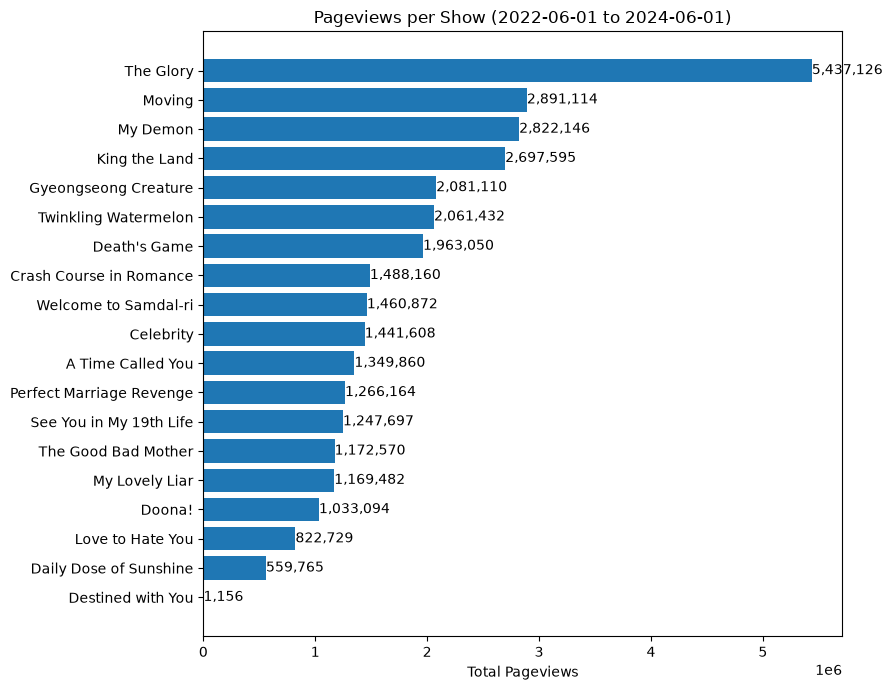

In [37]:
totals = {title: pv_df["views"].sum() for title, pv_df in all_data.items()}
totals_series = pd.Series(totals).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(totals_series.index, totals_series.values)
plt.xlabel("Total Pageviews")
plt.title("Pageviews per Show (2022-06-01 to 2024-06-01)")
plt.bar_label(bars, fmt='{:,.0f}')

plt.tight_layout()
plt.savefig("graph1.png", dpi=150)
plt.show()

In [27]:
#get peak
for title, pv_df in all_data.items():
    pv_df = pv_df.sort_values("date").reset_index(drop=True)
    peak_date = pv_df.loc[pv_df["views"].idxmax(), "date"]
    pv_df["day_offset"] = (pv_df["date"] - peak_date).dt.days
    all_data[title] = pv_df

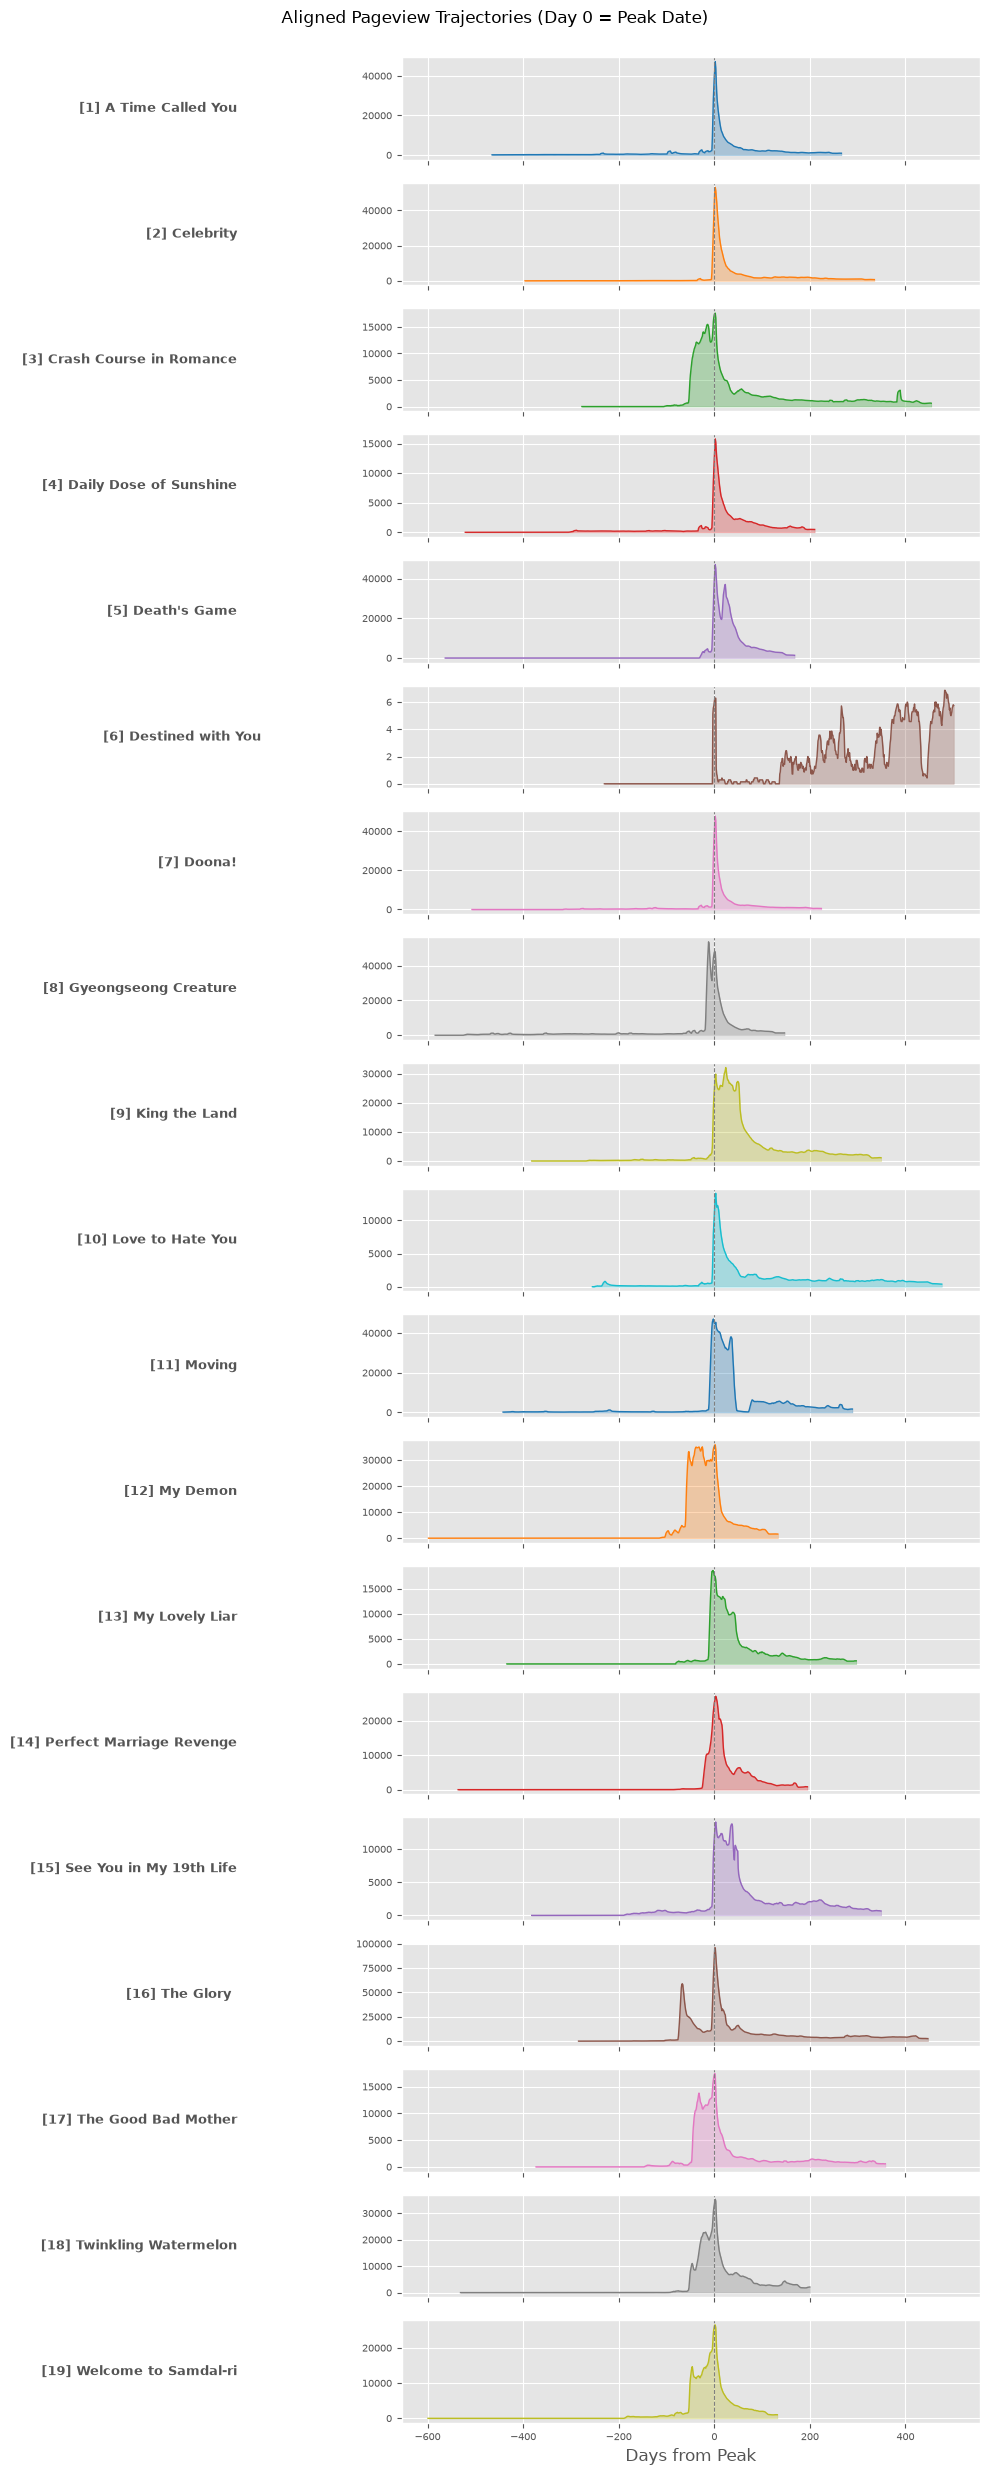

In [44]:
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(all_data), 1, figsize=(10, 1.3 * len(all_data)), sharex=True)

for i, (title, pv_df) in enumerate(all_data.items()):
    ax = axes[i]
    color = colors[i % len(colors)]

    ax.plot(pv_df["day_offset"], pv_df["views_smooth"], color=color, linewidth=1)
    ax.fill_between(pv_df["day_offset"], pv_df["views_smooth"], color=color, alpha=0.3)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

    ax.set_ylabel(f"[{i+1}] {title}", rotation=0, labelpad=90,
                   fontsize=9, fontweight="bold", ha="right", va="center")
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel("Days from Peak")
fig.suptitle("Aligned Pageview Trajectories (Day 0 = Peak Date)", y=1.0)
plt.tight_layout()
plt.savefig("graph2.png", dpi=150)
plt.show()